In [3]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import warnings
import pickle as pkl
warnings.filterwarnings('ignore')

In [4]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 2
%aimport Sub
%aimport Master
%aimport FullInfo
%aimport DataPreparation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Functions

### Prepare Data

In [ ]:
from DataPreparation import getMGData, buildCEMSData
def prepare_data(N, T):
    N_range = range(N)
    # Get data
    data_private, data_public = map(list, zip(*[getMGData(n) for n in N_range]))
    data_cems = buildCEMSData(data_public)
    # Calculate alpha
    sv = np.array([mg_n['sv'] for mg_n in data_private])
    sv_sum_exp = np.exp(sv).sum()
    alpha = np.exp(sv) / sv_sum_exp
    for n in range(N):
        data_private[n]['alpha'] = alpha[n]
    return data_private, data_cems

Set parameter TokenServer to value "ioml.ie.e.uh.edu"
Set parameter Method to value 0


### Full Information Model

In [ ]:
from FullInfo import *
def solve_full_model(N, T, data_private):
    jiant = FullModel(N=N, T=T, mg_data=data_private)
    # Solve central
    jiant.model.optimize()
    if jiant.model.SolCount > 0:
        result = jiant.get_var_values()
        with open(f'Solution/(N={N},T={T})FullInfo-solu.pkl', 'wb') as f:
            pkl.dump(result, f)
    else:
        raise ValueError(f'Optimization failed with model status {jiant.model.Status}.')

# Lp Box ADMM Algorithm

In [5]:
# Sphere manifold class
class Manifold:
    def __init__(self, n_z):
        # Center of manifold
        self.c = 0.5 * np.ones(n_z)
        # Radius of the manifold
        self.r = np.sqrt(n_z) / 2

    def proj_to_tangent(self, z, vec):
        # Radial vector
        radial = z - self.c
        # Scalar value (z-c).T G / r^2
        scalar = (radial @ vec) / self.r**2
        # Removing the radial component of the gradient
        vec_tangent = vec - scalar * radial
        return vec_tangent
    
    def retract(self, z):
        radial = z - self.c
        radial_norm = np.linalg.norm(radial)
        return self.r * (radial / radial_norm) + self.c

In [ ]:
# System (N: number of microgrids, T: trading horizon (hours))
N, T = 3, 24

# Initializations
'''
y_shape:    the shape of all e_buy, e_sell, pi_buy, pi_sell variables stacked in the exact order.
            N, N, T refers to from MG i to j at time t.
            (0, 0, 1, 1): power bought by MG 0 from MG 1 at time 1.
            (2, 0, 1, 1): payment for power bought by MG 0 from MG 1 at time 1.
x_shape:    the shape of all original_binary variables associated with buy/sell mode.
'''
from copy import copy
y_shape = (4, N, N, T)
x_shape = (N, T)
yhat = 100 * np.ones(y_shape)       # Auxiliary variables value for y (all \hat variables)
l_y = np.zeros(y_shape)             # Dual multipliers value for yhat=y
z1 = np.zeros(x_shape)              # Auxiliary variables value for x in box
z2 = np.zeros(x_shape)              # Auxiliary variables value for x on manifold
l_z1 = np.zeros(x_shape)            # Dual multipliers value for z1=x
l_z1 = np.zeros(x_shape)            # Dual multipliers value for z2=x
yhat_old = copy(yhat)                  # Copy 
z1_old, z2_old = copy(z1), copy(z2)
rho_y, rho_z = 1e-8, 100            # Penalty parameters
mu, tau = 10, 2                     # Parameters to control updates of penalties
eps_y, eps_z = 0.5, 0.5             # Termination criteria for y and z parts of Lagrnagian 
M = Manifold(T)                     # Manifold class for projection and retraction

# Algorithm
from time import time

prs, drs = [], []
itr = 0
max_itr = 500
start = time()
for itr in tqdm(range(max_itr)):
    # Solve f
    y, x = [], []
    for i, fi in enumerate(f):
        kwargs = {
            'yhat': yhat[:, i, :, :],
            'l_y': l_y[:, i, :, :],
            'rho_y': rho_y,
            'z1': z1[i, :],
            'l_z1': l_z1[i, :],
            'rho_z1': rho_z1,
            'z2': z2[i, :],
            'l_z2': l_z2[i, :],
            'rho_z2': rho_z2,
            }
        yi, xi = fi.solve_with_lp(**kwargs)
        y.append(yi)
        x.append(xi)
    y = np.transpose(np.stack(y, axis=0), (1, 0, 2, 3))
    x = np.stack(x, axis=0)

    # Solve g
    yhat = g.solve_with(y=y, rho_y=rho_y, l_y=l_y)

    # Update z1
    z1 = np.clip(x + l_z1/rho_z1, 0, 1)

    # Update z2
    z2 = retract(x + 0.05 * l_z2/rho_z2, c, r)

    # Gradient ascent
    l_y += rho_y * (y - yhat)
    l_z1 += rho_z1 * (x - z1)
    l_z2 += rho_z2 * (x - z2)

    # Residuals
    pr = [np.linalg.norm(y - yhat)/y_size, 
          np.linalg.norm(x - z1)/x_size, 
          np.linalg.norm(x - z2)/x_size]
    dr = [rho_y * np.linalg.norm(yhat - yhat_old)/y_size, 
          rho_z1 * np.linalg.norm(z1 - z1_old)/x_size, 
          rho_z2 * np.linalg.norm(z2 - z2_old)/x_size]
    done = all([pr[0] + dr[0] <= e_y, pr[1] + dr[1] <= e_z, pr[2] + dr[2] <= e_z])
    (prs.append(pr), drs.append(dr))

    # Update itr
    itr += 1
    yhat_old, z1_old, z2_old = yhat, z1, z2

    # Update rhos
    y_oldcoef = tau if pr[0] >= mu * dr[0] else 1 / tau if dr[0] >= mu * pr[0] else 1
    rho_y = y_oldcoef * rho_y
    z1_oldcoef = tau if pr[1] >= mu * dr[1] else 1 / tau if dr[1] >= mu * pr[1] else 1
    rho_z1 = z1_oldcoef * rho_z1
    '''z2_oldcoef = tau if pr[2] >= mu * dr[2] else 1 / tau if dr[2] >= mu * pr[2] else 1
    rho_z2 = z2_oldcoef * rho_z2'''

    # Terminate
    if done:
        break
print(time() - start)

Progress:   7%|▋         | 7/100 [00:01<00:22,  4.21it/s]

1.6618151664733887


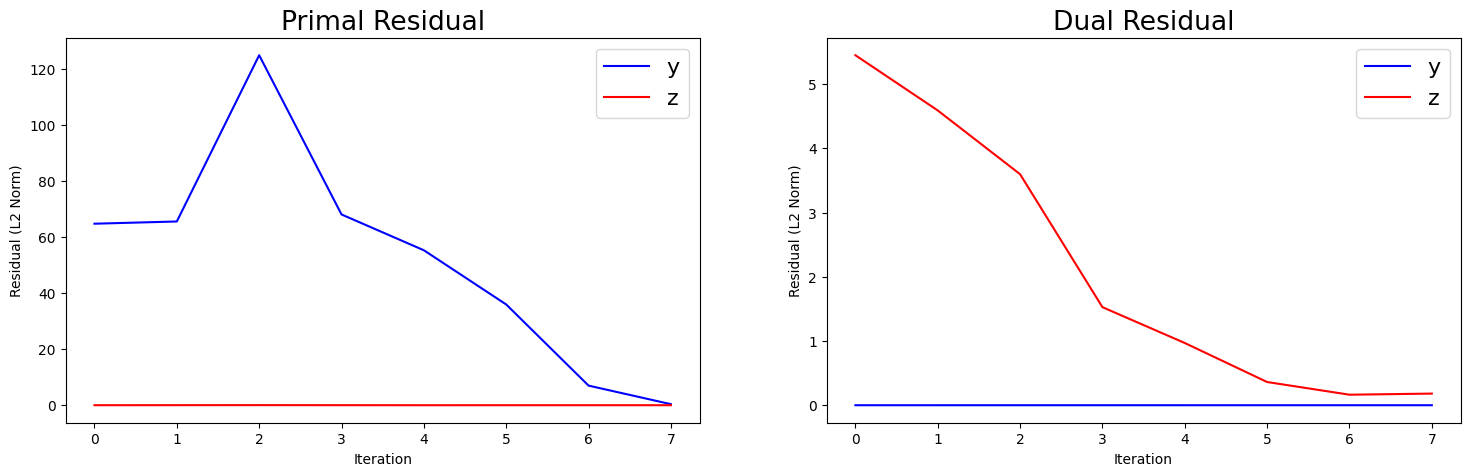

In [10]:
import matplotlib.pyplot as plt
y_primal, y_dual = np.stack(prs, axis=1), np.stack(drs, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams['font.size'] = 16
plt.subplots_adjust(hspace=0.6)

axs[0].plot(y_primal[0], label='y', color='blue')
axs[0].plot(y_primal[1], label='z', color='red')
axs[0].set_title('Primal Residual')

axs[1].plot(y_dual[0], label='y', color='blue')
axs[1].plot(y_dual[1], label='z', color='red')
axs[1].set_title('Dual Residual')
for ax in axs:
    ax.legend()
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (L2 Norm)')

plt.savefig(f'Performance/residuals.jpg', dpi=600)

In [150]:
for n in range(N):
    kwargs = {
            'yhat': yhat[:, n, :, :],
            'l_y': l_y[:, n, :, :],
            'rho_y': rho_y,
            'z': z[n, :],
            'l_z': l_z[n, :],
            'rho_z': rho_z,
            }
    f[n].save_solutions(**kwargs, name=name)

In [11]:
yhat

array([[[[ 0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ],
         [ 0.02449468,  0.02449468,  0.02449468,  0.02449468,
           0.02449468,  0.01382953,  0.02449468,  0.02449468,
           0.02449468,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.02449865,
           0.02449468,  0.02449468,  0.02449468,  0.02449468,
           0.02449468,  0.03515983,  0.02449468,  0.02449484],
         [ 0.02325002,  0.02325002,  0.02325002,  0.02325002,
           0.02325002,  0.        ,  0.02325002,  0.02325002,
           0.02325002,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        ,  0.        ,  0.02325398,
      

In [5]:
from Results import *
name_to_save = f'RPADMM(t={f[0].config.tau})_'
results0 = {n: MGResults(f'NoTrade_MG({n})', mg_private[n]) for n in range(N)}
results1 = {n: MGResults(f'{name_to_save}MG({n})', mg_private[n]) for n in range(N)}

In [8]:
# Cost table
get_cost_table(results0, results1, N, name_to_save)

# Resilience and cost reduction
get_metric_table(results0, results1, N, name_to_save)

# KPI
get_kpi_table(results1, N, name_to_save)

# Power table
get_power_table(results1, N, name_to_save)

# Trade plot
plot_trade(results1, name_to_save)

# Load satisfaction plot
plot_load_served(results1, 1, name_to_save)

# plot
plot_trade(results1, name_to_save)
plot_demand(results0, results1, name_to_save)

In [17]:
plot_demand(results0, results1, name_to_save)

### lp-ADMM

In [283]:
y_shape, x_shape = g.yhat.shape, (N, T)
y_size, x_size = g.yhat.size, N*T
yhat, l_y = np.zeros(y_shape), np.zeros(y_shape)
z1, l_z1 = np.zeros(x_shape), np.zeros(x_shape)
z2, l_z2 = np.zeros(x_shape), np.zeros(x_shape)
c, r = 0.5 * np.ones((N, T)), np.sqrt(T)/2
rho_y, rho_z1, rho_z2 = 0.01, 0.001, 0.01
mu, tau = 5, 2
e_y, e_z = 0.05, 0.01

100%|██████████| 500/500 [01:05<00:00,  7.58it/s]

65.99592638015747


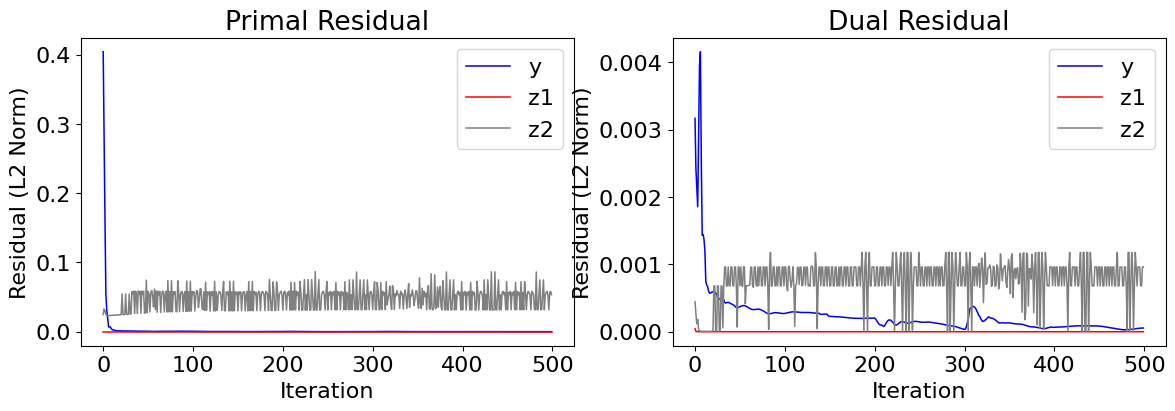

In [285]:
import matplotlib.pyplot as plt
primals, duals = np.stack(prs, axis=0), np.stack(drs, axis=0)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.1
plt.subplots_adjust(hspace=0.6)
axs[0].plot(primals[:, 0], label='y', color='blue')
axs[0].plot(primals[:, 1], label='z1', color='red')
axs[0].plot(primals[:, 2], label='z2', color='gray')
axs[0].set_title('Primal Residual')
axs[1].plot(duals[:, 0], label='y', color='blue')
axs[1].plot(duals[:, 1], label='z1', color='red')
axs[1].plot(duals[:, 2], label='z2', color='gray')
axs[1].set_title('Dual Residual')
for ax in axs:
    ax.legend()
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (L2 Norm)')
#plt.savefig(f'Performance/residuals.jpg', dpi=600)

In [278]:
print(y[0,0,1],'\n', y[1,1,0])

[22.10998685 22.11004398 22.1100335  22.10996363 22.1099259  22.10996653
 22.11002981 22.10992403 13.98957655 14.05401499 12.78618484 12.77413376
 12.77287084 12.79530799 12.71272361 35.78559595 17.5468114  21.28414187
 21.28413954 21.28413939 21.28413957 21.28414343 21.28403108 40.25532514] 
 [22.10826715 22.10832427 22.10831379 22.10824392 22.10820619 22.10824682
 22.1083101  22.10820432 13.9878568  14.04875628 12.77781961 12.76577611
 12.76450578 12.78694279 12.70681004 35.78054667 17.54509167 21.28242216
 21.28241983 21.28241968 21.28241986 21.28242372 21.28231137 40.25213508]


In [279]:
x

array([[0.32310873, 0.32310818, 0.32310869, 0.32310871, 0.67237309,
        0.32310875, 0.32310875, 0.32310824, 0.18562161, 0.14054984,
        0.12787542, 0.12775503, 0.12774249, 0.12796609, 0.56259273,
        0.76381906, 0.28459518, 0.33576365, 0.33576366, 0.66411504,
        0.33576367, 0.66411508, 0.33576316, 0.40255491],
       [0.77891728, 0.77891671, 0.77891681, 0.77891751, 0.77891789,
        0.77891748, 0.77891685, 0.77891791, 0.8601214 , 0.8595124 ,
        0.87222177, 0.42109745, 0.421111  , 0.87213054, 0.87293186,
        0.19092185, 0.82454904, 0.78717573, 0.78717576, 0.78717576,
        0.78717576, 0.78717572, 0.78717684, 0.14620596],
       [0.19778359, 0.19778413, 0.19778362, 0.1977836 , 0.19778399,
        0.19778356, 0.19778356, 0.19778407, 0.81440822, 0.91352149,
        0.92367798, 0.92229276, 0.44321849, 0.44215599, 0.91656404,
        0.236275  , 0.23630042, 0.18512829, 0.1851283 , 0.1851283 ,
        0.1851283 , 0.18512826, 0.18512876, 0.20975355]])

In [173]:
print(np.linalg.norm(z2[1]-c[0]), r)

2.4494897427831774 2.449489742783178
